# 06_特征选择方法-主成分分析

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们这篇文章来聊聊特征选择方法中的主成分分析\~

打个比方，现在要分析一个人的性格，有很多维度，比如“是否外向”、“是否爱说话”、“是否喜欢交朋友”……可能有几十上百个维度。

这么多维度不但数据处理起来很慢，还可能有“重复”或“没用”的维度。

所以我们希望**挑出最有用的几个维度**，这就叫**特征选择**。

### 什么是主成分分析（PCA）？

再来举个例子：

你去超市买苹果，卖家告诉你每个苹果都有 **重量、大小、甜度、颜色、硬度** 等很多个指标。你一听头都大了，太多了，不知道该怎么看。

于是你想了个办法：

把这些指标“合并一下”，比如找一个**综合评分**，它能大致反映这个苹果好不好吃，那你就不用一个个看细节了。

这个“综合评分”就是主成分分析想做的事情，**把很多个特征合并成更少的几个代表性的新特征（叫主成分）**，既不浪费信息，又更好处理。

PCA的作用简单说就是：

- 把原来一堆特征变成更少的新特征；
- 这些新特征是从原来的特征“压缩”出来的；
- 每个新特征都是“最能反映数据差异”的方向；
- 最终达到**降低维度、去冗余、加快计算、方便可视化**的目的。

## 原理详解

首先，PCA的目标是：**在保留数据变化信息最多的前提下，将原始高维数据投影到更低维空间。**

它通过构造一些新的变量（称为“主成分”）来替代原来的变量，这些主成分具有以下特点：

- 是原始变量的线性组合；
- 相互正交（即不相关）；
- 按照能够解释的数据“方差”从大到小排序；
- 通常选择前几个主成分来替代全部变量（达到降维目的）。

### 数学原理

从原理层面来推导PCA的数学过程。

#### 1. 数据准备与标准化

**输入数据矩阵：**

设有数据集 $X \in \mathbb{R}^{n \times d}$，表示 $n$ 个样本，每个样本有 $d$ 个特征。

即：


$$
X = \begin{bmatrix}x_1^{(1)} & x_1^{(2)} & \cdots & x_1^{(d)} \\x_2^{(1)} & x_2^{(2)} & \cdots & x_2^{(d)} \\\vdots & \vdots & \ddots & \vdots \\x_n^{(1)} & x_n^{(2)} & \cdots & x_n^{(d)} \\\end{bmatrix}
$$


为了消除不同特征的量纲影响，我们**中心化**数据（去均值）：


$$
\tilde{X} = X - \bar{X}, \quad \text{其中 } \bar{X} \text{ 是每列的均值}
$$


（有时也标准化为零均值单位方差，这取决于实际场景）

#### 2. 协方差矩阵构造

我们关注的是每个特征之间的“线性相关性”，这体现在**协方差矩阵**中。

定义协方差矩阵为：


$$
C = \frac{1}{n-1} \tilde{X}^T \tilde{X} \quad \text{（维度为 } d \times d \text{）}
$$


- $C_{ij}$ 表示第 $i$ 个特征和第 $j$ 个特征之间的协方差；
- 对角线上的值是各特征的方差；
- 非对角线是两个特征的相关程度。

#### 3. 寻找最优投影方向（最大方差）

主成分的目的是：

> 找一个方向 $\mathbf{w} \in \mathbb{R}^d$，使得数据投影到该方向上的方差最大。

投影一个样本 $\mathbf{x}$ 到 $\mathbf{w}$ 上后的值为：


$$
z = \mathbf{w}^T \mathbf{x}
$$


所有样本投影后的方差为：


$$
\text{Var}(z) = \mathbf{w}^T C \mathbf{w}
$$


我们要最大化这个方差，但同时约束 $\mathbf{w}$ 是单位向量（否则可以无限放大）：

> **优化问题：**


$$
\max_{\mathbf{w}} \quad \mathbf{w}^T C \mathbf{w} \quad \text{s.t.} \quad \mathbf{w}^T \mathbf{w} = 1
$$


这就是一个典型的**带约束的最大化问题**，可以用**拉格朗日乘子法**解决：

#### 4. 拉格朗日乘子法求解

构造拉格朗日函数：


$$
L(\mathbf{w}, \lambda) = \mathbf{w}^T C \mathbf{w} - \lambda (\mathbf{w}^T \mathbf{w} - 1)
$$


对 $\mathbf{w}$ 求偏导并令其为 0：


$$
\nabla_{\mathbf{w}} L = 2C \mathbf{w} - 2\lambda \mathbf{w} = 0 \Rightarrow C \mathbf{w} = \lambda \mathbf{w}
$$


这正是**特征值问题**！

#### 5. 特征值与主成分的关系

上面我们得到了：


$$
C \mathbf{w} = \lambda \mathbf{w}
$$


- $\lambda$ 是协方差矩阵 $C$ 的特征值；
- $\mathbf{w}$ 是对应的特征向量；
- $\lambda$ 表示沿该方向投影后的方差。

所以我们只要：

1. 求出 $C$ 的所有特征值与特征向量；
2. 按照特征值从大到小排序；
3. 选取前 $k$ 个特征向量组成新的变换矩阵 $W_k \in \mathbb{R}^{d \times k}$。

#### 6. 数据变换（降维）

将原始数据 $X$ 映射到新的低维空间：


$$
Z = \tilde{X} \cdot W_k
$$


其中：

- $W_k$ 是前 $k$ 个主成分向量组成的矩阵；
- $Z \in \mathbb{R}^{n \times k}$ 是降维后的数据；
- 这就是新的低维表示，具有最多的“数据方差信息”。

## 完整算法流程

步骤 1：标准化数据（中心化）

- 对每一列减去其均值（也可以进一步标准差归一化）；
- 得到中心化后的矩阵 $\tilde{X}$。

**步骤 2：计算协方差矩阵**


$$
C = \frac{1}{n-1} \tilde{X}^T \tilde{X}
$$


**步骤 3：计算特征值与特征向量**

- 对协方差矩阵 $C$ 进行特征分解：$C \mathbf{w}_i = \lambda_i \mathbf{w}_i$
- 得到 $d$ 个特征值 $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_d$；
- 对应的特征向量 $\mathbf{w}_1, \mathbf{w}_2, \ldots \mathbf{w}_d$。

**步骤 4：选择前** $k$ **个主成分**

- 选取前 $k$ 个最大特征值对应的特征向量；
- 组成变换矩阵 $W_k = [\mathbf{w}_1, \ldots, \mathbf{w}_k] \in \mathbb{R}^{d \times k}$。

**步骤 5：数据投影（降维）**

- 将原始数据投影到新空间：$Z = \tilde{X} \cdot W_k \in \mathbb{R}^{n \times k}$

### 如何选取主成分数量 $k$？

通过累计方差贡献率判断：


$$
\text{贡献率} = \frac{\sum_{i=1}^k \lambda_i}{\sum_{j=1}^d \lambda_j}
$$


通常选取能解释**90%\~95%**方差的主成分个数 $k$。

## 完整案例

假设我们手头有一份经典的“**鸢尾花数据集**”，这是机器学习中常用的一个多分类数据集。

有4个特征：

- 花萼长度（sepal length）
- 花萼宽度（sepal width）
- 花瓣长度（petal length）
- 花瓣宽度（petal width）

目标是预测鸢尾花的种类（3个类别）。

**为什么用PCA？**

4个特征不算多，但我们想：

- 降低特征维度，简化模型；
- 发现隐藏的潜在“综合特征”；
- 减少噪声和冗余，提高模型性能；
- 做可视化，把数据投影到2维方便观察。

PCA通过线性变换，将4维特征压缩成2或3维主成分，保留最多信息。主成分可以替代原始特征，作为新的特征输入机器学习模型。

### 数据加载与预处理

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 载入数据
iris = load_iris()
X = iris.data      # 特征矩阵，shape (150, 4)
y = iris.target    # 标签向量，shape (150,)
feature_names = iris.feature_names

# 打印数据基本信息
print("数据维度：", X.shape)
print("特征名称：", feature_names)
print("类别分布：", np.bincount(y))

# 特征标准化（中心化+归一化）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 查看标准化后数据均值和方差
print("标准化后均值（应接近0）：", np.mean(X_scaled, axis=0))
print("标准化后方差（应接近1）：", np.var(X_scaled, axis=0))

数据维度： (150, 4)
特征名称： ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别分布： [50 50 50]
标准化后均值（应接近0）： [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
标准化后方差（应接近1）： [1. 1. 1. 1.]


- 标准化是PCA前的关键步骤，避免特征因单位不同而导致方差差异过大。
- `StandardScaler`会将每个特征变成均值0，方差1。

### 执行PCA算法并解释结果

In [3]:
from sklearn.decomposition import PCA

# 实例化PCA，保留全部4个主成分，方便分析贡献率
pca = PCA(n_components=4)
pca.fit(X_scaled)

# 打印各主成分的方差贡献率
explained_variance_ratio = pca.explained_variance_ratio_
print("各主成分方差贡献率：", explained_variance_ratio)
print("累计贡献率：", np.cumsum(explained_variance_ratio))

# 打印主成分特征向量（即权重矩阵）
print("主成分特征向量（每列对应一个主成分）：")
print(pca.components_.T)

各主成分方差贡献率： [0.72962445 0.22850762 0.03668922 0.00517871]
累计贡献率： [0.72962445 0.95813207 0.99482129 1.        ]
主成分特征向量（每列对应一个主成分）：
[[ 0.52106591  0.37741762  0.71956635 -0.26128628]
 [-0.26934744  0.92329566 -0.24438178  0.12350962]
 [ 0.5804131   0.02449161 -0.14212637  0.80144925]
 [ 0.56485654  0.06694199 -0.63427274 -0.52359713]]


- `explained_variance_ratio_` 表示每个主成分所解释的方差比例。
- 通常我们会选取累积贡献率达到 90% 以上的主成分数。
- `pca.components_` 是每个主成分对应原始特征的权重，帮助理解主成分含义。

### 用PCA做降维与可视化

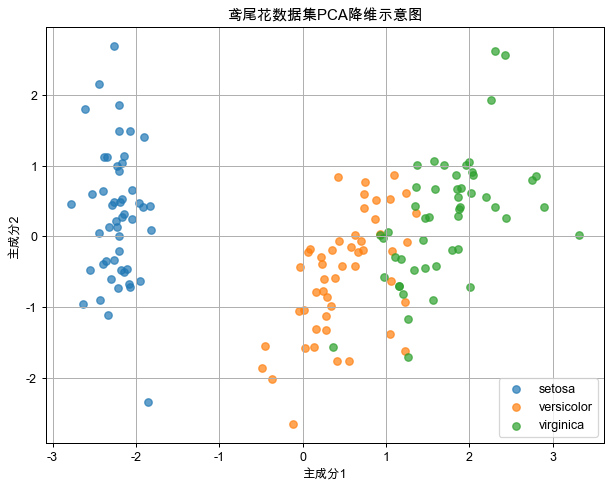

In [4]:
# 只取前两个主成分做降维
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# 绘制降维后样本的散点图，按类别着色
plt.figure(figsize=(8,6))
for label in np.unique(y):
    plt.scatter(X_pca[y==label, 0], X_pca[y==label, 1],
                label=iris.target_names[label], alpha=0.7)
plt.xlabel("主成分1")
plt.ylabel("主成分2")
plt.title("鸢尾花数据集PCA降维示意图")
plt.legend()
plt.grid(True)
plt.show()

- 图中可以看到不同类别花在主成分空间的分布情况。
- 主成分1和2结合能较好地区分三个类别。
- 这是PCA降维最直观的用途。

![原文参考图，当前结果见代码输出](attachments/img_019.png)

### 选取主成分个数的方法分析

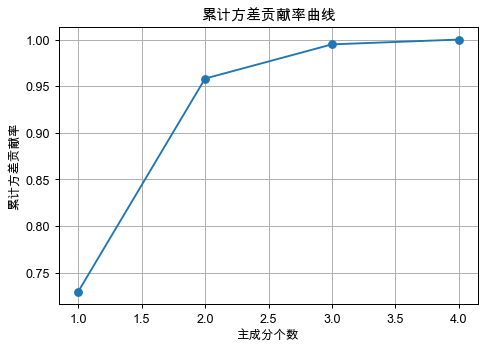

In [5]:
# 绘制累计方差贡献率曲线
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, 5), np.cumsum(explained_variance_ratio), marker='o')
plt.xlabel("主成分个数")
plt.ylabel("累计方差贡献率")
plt.title("累计方差贡献率曲线")
plt.grid(True)
plt.show()

- 从曲线观察可以判断多少主成分可以满足信息保留需求（比如90%）
- 在鸢尾花数据中，前2个主成分通常就能解释95%以上的方差，说明降维效果好。

![原文参考图，当前结果见代码输出](attachments/img_020.png)

### 基于PCA做分类的实验演示

为了验证PCA特征选择对模型的影响，我们做一个简单的分类实验：

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 分割数据集（70%训练，30%测试）
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 1) 使用原始4维特征训练分类器
clf_raw = LogisticRegression(max_iter=200)
clf_raw.fit(X_train, y_train)
y_pred_raw = clf_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw)

# 2) 使用PCA降到2维特征训练分类器
pca_2 = PCA(n_components=2)
X_train_pca = pca_2.fit_transform(X_train)
X_test_pca = pca_2.transform(X_test)

clf_pca = LogisticRegression(max_iter=200)
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f"原始4维特征分类准确率: {acc_raw:.4f}")
print(f"PCA降维2维特征分类准确率: {acc_pca:.4f}")

原始4维特征分类准确率: 1.0000
PCA降维2维特征分类准确率: 0.9111


- PCA降维后特征减少，但分类准确率基本保持，甚至可能更稳定。
- 降维带来计算效率提升和模型泛化能力提高。

### 算法优化与实用技巧

**1. 标准化非常关键**

- PCA依赖特征的方差，单位不统一会导致结果偏向方差大的特征。标准化步骤不可省。

**2. 选择合适的主成分数目**

- 用累计方差贡献率确定。
- 结合具体任务需求，兼顾维度压缩和信息保留。

**3. 使用奇异值分解（SVD）进行PCA计算**

- 传统协方差矩阵计算在高维数据上计算量大。
- sklearn中PCA内部其实是基于SVD实现的，效率更高。

**4. 注意样本数量与特征数量的关系**

- 当样本数远小于特征数时（小样本高维），PCA可能不稳定。
- 需配合正则化或其它降维手段。

**5. 可结合其他特征选择方法**

- PCA是无监督的降维，不考虑标签信息。
- 若需监督特征选择，可以结合LDA、随机森林特征重要性等。

## 模型分析

### 主成分分析（PCA）的优缺点

**优点：**

1. **降维效果显著，保留主信息**：PCA通过最大化数据方差，找出最能解释数据变化的方向，通常可以用较少的主成分保留90%以上的信息。这对冗余特征或共线性问题特别有效。
2. **提高模型训练效率**：减少特征数量可显著降低模型训练时间和资源消耗，尤其在高维数据集上表现明显。
3. **消除多重共线性**：主成分彼此正交（无相关性），能很好解决特征间高度相关的问题，避免影响回归模型或线性模型性能。
4. **支持可视化降维**：将高维数据压缩至2维或3维，有助于探索数据分布和类别边界，辅助模型分析。
5. **不依赖于标签信息（无监督方法）**：可用于分类、聚类、异常检测等无标签场景，是非常通用的特征转换方法。

**缺点：**

1. **主成分难以解释物理含义**：新生成的特征是原始特征的线性组合，虽然数学上有用，但很难对应现实意义，降低模型的可解释性。
2. **无法利用标签信息进行有监督选择**：PCA不考虑目标变量y，仅关注自变量x的方差分布，这可能导致丢失对分类/回归有意义的信息。
3. **对异常值敏感**：极端值会显著影响协方差矩阵和主成分方向，因此需要谨慎数据预处理（如标准化、异常值处理）。
4. **仅限于线性变换，处理非线性关系有限**：如果数据中的重要结构是非线性的，PCA无法有效捕捉（如图像、文本中的复杂特征），需使用非线性降维方法如Kernel PCA或t-SNE。
5. **不等价于特征选择，而是特征转换**：PCA生成了新的“主成分特征”，不能直接解释为“挑选了某些原始特征”，这和传统特征选择方法（如递归特征消除）不同。

### 与其他特征选择方法的对比

| 特征选择方法 | 方法类型 | 是否监督 | 特征是否可解释 | 是否生成新特征 | 是否处理共线性 | 非线性能力 |
|-|-|-|-|-|-|-|
| PCA | 投影变换 | 否 | 较差 | 生成新特征 | 强 | 弱 |
| 方差选择法（Variance Threshold） | 过滤法 | 否 | 好 | 不生成新特征 | 弱 | 弱 |
| 相关系数法 | 过滤法 | 是 | 好 | 不生成新特征 | 弱 | 弱 |
| 递归特征消除（RFE） | 包装法 | 是 | 很好 | 不生成新特征 | 中等 | 弱 |
| L1正则（Lasso） | 嵌入法 | 是 | 很好 | 不生成新特征 | 强 | 弱 |
| 随机森林重要性 | 嵌入法 | 是 | 好 | 不生成新特征 | 中等 | 一定程度 |
| Kernel PCA | 投影变换 | 否 | 很差 | 生成新特征 | 强 | 强 |

### PCA的适用场景 vs 替代方法建议

**建议优先使用PCA的情况：**

1. **维度高、特征间强相关，存在冗余或共线性**  
如：图像、信号数据、传感器数据等，特征存在重叠性。
2. **模型对解释性要求不高，重点关注准确率或压缩效果**  
如：目标是提高分类/聚类准确率或数据可视化，而非解释变量含义。
3. **原始数据无标签或标签不可靠**  
如：无监督学习场景（聚类、异常检测、数据探索等）。
4. **特征数量远大于样本数量（高维小样本）**  
如：基因芯片数据、文本词向量（TF-IDF）等情况，PCA能避免过拟合。
5. **预处理作为其他模型的输入（如神经网络）**  
PCA作为数据压缩步骤能提升训练速度与收敛性。

### 可考虑其他方法的情况：

1. **希望选择原始特征，保持模型可解释性**  
推荐：`SelectKBest`, `Lasso`, `RFE`, `RandomForestFeatureImportances`
2. **数据中含有重要的标签信息，需监督特征选择**  
推荐：基于标签的过滤法（如F检验）、递归特征消除、嵌入式模型方法等。
3. **数据分布复杂、非线性结构显著**  
推荐：`Kernel PCA`, `t-SNE`, `UMAP` 等非线性降维方法。
4. **对异常值敏感的任务**  
推荐：鲁棒特征选择方法，如使用中位数代替均值计算方差，或先处理异常值。

## 结论

主成分分析是一种经典且高效的无监督特征选择和降维方法，尤其适用于：

- 高维冗余特征；
- 对模型速度和性能要求较高；
- 无标签或探索性数据分析场景。

但当我们追求模型**可解释性**、**需要监督信息**或处理**非线性数据结构**时，应该慎用PCA，或与其他特征选择方法结合使用，形成更加稳健的特征处理策略。